In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
RUNS = {
    "dyn fb": 
        {
            "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/Baseline',
            "color": 'red'
        }, 
    "dyn fb (Long)": 
        {
            "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/Baseline_800',
            "color": 'darkred'
        }, 
    "silent fb": 
        {
            "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/Silent_Feedback',
            "color": 'dodgerblue'
        },
    "random":
        {
            "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/IS_RandomControl',
            "color": 'gray'
        },
    # "inst fb (1/10)":
    #     {
    #         "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/Inst_Competition',
    #         "color": 'orchid' 
    #     },
    # "inst fb (1/d)":
    #     {
    #         'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_08_10_04_trial_-1',
    #         'color': 'limegreen'
    #     },
    # "1_400 (31)":
    #     {
    #         'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_14_10_01_trial_31',
    #         'color': 'orange'
    #     },
    "1_400 (160)":
    {
        'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_14_20_54_trial_160',
        'color': 'green'
    },
    # "1_400 (160) Long":
    #     {
    #         'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_15_00_56_trial_160_Long',
    #         'color': 'darkgreen'
    #     },
    "Test":
    {
        'folder': '/Users/juliuswuerzler/Desktop/2Pong/RUNS_NEW_PARAMS/01_16_22_44_trial_-1',
        'color': 'black'
    },
        "Test new":
    {
        'folder': '/Users/juliuswuerzler/Desktop/2Pong/RUNS_NEW_PARAMS/NEW_Long',
        'color': 'blue'
    },
}

In [3]:
def ema(x, alpha=0.1):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [4]:
ALPHA = 0.05
N = 50

for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    rolling_means = []
    ss = []
    es = []
    
    for f in result_files:
        network = f.split('_')[-2:-1][0]
        results = np.loadtxt(f)
        
        RUNS[run]['results'][network] = {}
        
        # get smoothed values
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # get start and end
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        ss.append(start_results)
        es.append(end_results)
        
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(ss)
    RUNS[run]['end'] = np.array(es)

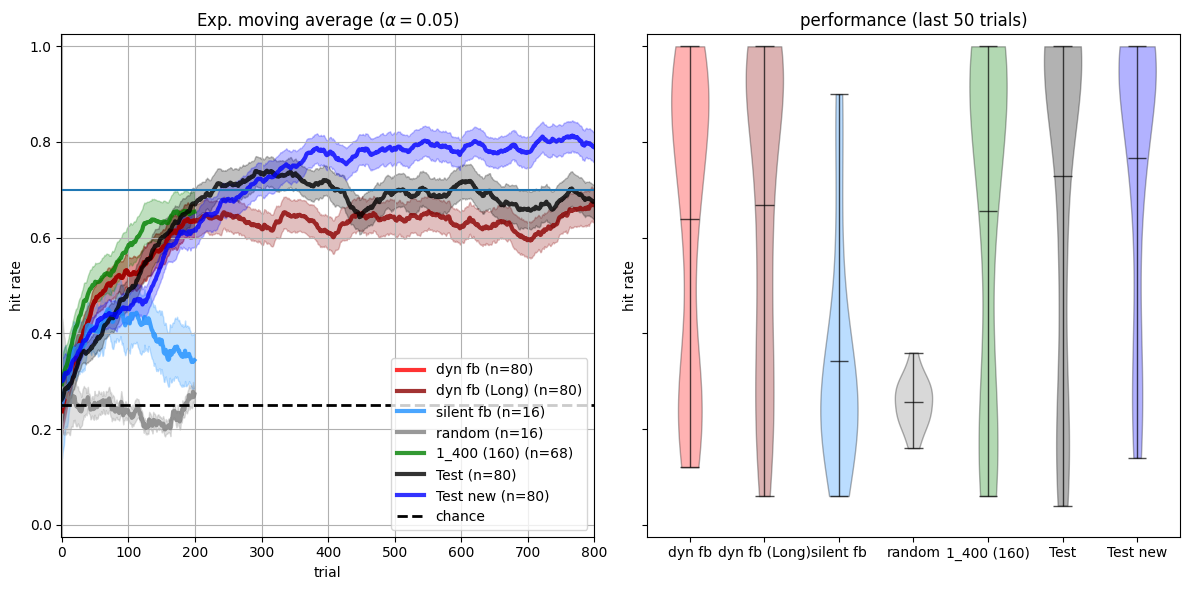

In [15]:
fig, axs = plt.subplots(1,2, figsize=(12,6), sharey=True)


for i, run in enumerate(RUNS):
    
    data = RUNS[run]['rolling means']
    color = RUNS[run]['color']
    
    # Mean and SEM across networks
    _mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

    x = np.arange(len(_mean))

    # Plot mean
    axs[0].plot(x, _mean, color=color, alpha=0.8, linewidth=3, label=f'{run} (n={len(data)})')

    # Plot SEM as shaded region
    axs[0].fill_between(
        x,
        _mean - sem,
        _mean + sem,
        color=color,
        alpha=0.25,
    )
    
    # plot end performances
    violin_parts = axs[1].violinplot(
        RUNS[run]['end'],
        positions=[i],
        showmeans=True,
        showextrema=True,
        widths=0.5,
        showmedians=False
    )
    # Apply colors
    for body in violin_parts['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor('black')
        # body.set_alpha(0.6)
    for partname in ('cmeans', 'cbars', 'cmins', 'cmaxes', 'cmedians'):
        if partname in violin_parts:
            violin_parts[partname].set_color('black')
            violin_parts[partname].set_linewidth(1)
            violin_parts[partname].set_alpha(0.7)
    
    
axs[0].axhline(0.25, linestyle='--', color='black', linewidth=2, label='chance')
axs[0].set_title(fr'Exp. moving average ($\alpha=${ALPHA})')
axs[0].set_ylabel('hit rate')
axs[0].set_xlabel('trial')
axs[0].legend()
axs[0].set_ylim([-0.025,1.025])

axs[1].set_xticks(np.arange(len(RUNS)))
axs[1].set_xticklabels([run for run in RUNS])
axs[1].set_ylabel('hit rate')
axs[1].set_title(f'performance (last {N} trials)')

axs[0].grid(True)
axs[0].axhline(0.7)

axs[0].set_xlim([-1,800])

plt.tight_layout()
plt.show()


In [6]:
# s_acc = np.zeros(len(result_files))
# e_acc = np.zeros_like(s_acc)

# rolling_means = []
# decreasing_runs = []

# for i, network in enumerate(sorted(all_results.keys(), key=int)):
#     s_acc[i] = np.mean(all_results[network]['results'][:N])
#     e_acc[i] = np.mean(all_results[network]['results'][-N:])
    
#     if e_acc[i] < s_acc[i] - 0.1: 
#         decreasing_runs.append((network, s_acc[i], e_acc[i], e_acc[i] - s_acc[i]))
    
# print(len(all_results))

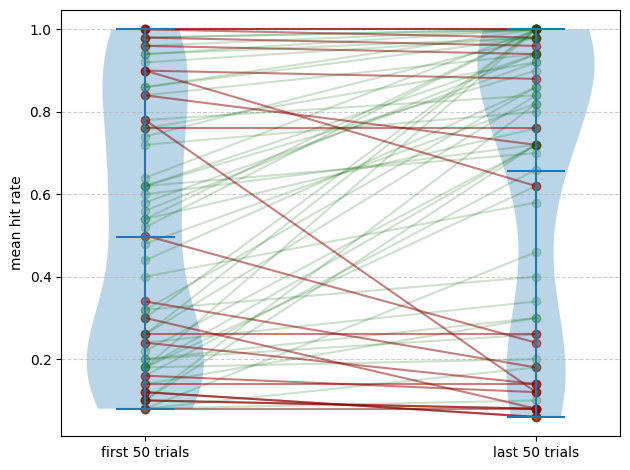

In [7]:
run = '1_400 (160)'

s_acc = RUNS[run]['start']
e_acc = RUNS[run]['end']

for i, (s, e) in enumerate(zip(s_acc, e_acc)):
    color = 'darkgreen' if e > s else 'darkred'
    alpha = 0.2 if e > s else 0.5
    plt.plot([0, 1], [s, e], marker='o', linestyle='-', alpha=alpha, color=color)
    

plt.violinplot([s_acc, e_acc], 
               positions=[0,1],
               showmeans=True, 
               # showmedians=True,
               showextrema=True, 
               widths=0.3)

plt.xticks([0, 1], [f'first {N} trials', f'last {N} trials'])
plt.ylabel('mean hit rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

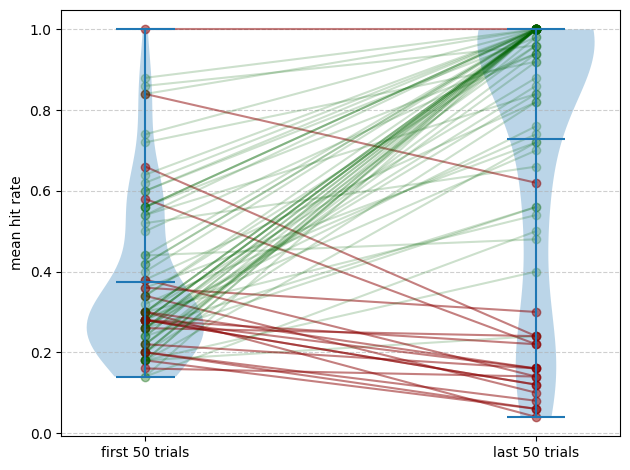

In [8]:
run = 'Test'

s_acc = RUNS[run]['start']
e_acc = RUNS[run]['end']

for i, (s, e) in enumerate(zip(s_acc, e_acc)):
    color = 'darkgreen' if e > s else 'darkred'
    alpha = 0.2 if e > s else 0.5
    plt.plot([0, 1], [s, e], marker='o', linestyle='-', alpha=alpha, color=color)
    

plt.violinplot([s_acc, e_acc], 
               positions=[0,1],
               showmeans=True, 
               # showmedians=True,
               showextrema=True, 
               widths=0.3)

plt.xticks([0, 1], [f'first {N} trials', f'last {N} trials'])
plt.ylabel('mean hit rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

In [9]:
print(f"{np.mean(s_acc):.3f}")
print(f"{np.mean(e_acc):.3f}")
print(f"{np.mean(e_acc - s_acc):.3f}")

0.374
0.729
0.355


In [10]:
# rolling_means = []
# for network in sorted(all_results_800.keys(), key=int):
#     rolling_means.append(ema(all_results_800[network]['results'], ALPHA))
# data = np.array(rolling_means)

# mean = data.mean(axis=0)
# sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

# x = np.arange(len(mean))

# # Plot mean
# plt.plot(x, mean, color=color, alpha=0.8, linewidth=3, label=f'{label} (n={len(data)})')
# plt.axhline(np.mean(e_acc), color='red', linestyle= '--',label='end mean acc. for 200 trials')

# # Plot SEM as shaded region
# plt.fill_between(
#     x,
#     mean - sem,
#     mean + sem,
#     color=color,
#     alpha=0.25,
# )

# plt.xlabel('trial')
# plt.ylabel('hit rate')

# plt.legend()

# plt.show()

In [11]:
from scipy.stats import shapiro

diff = e_acc - s_acc
shapiro(diff)

ShapiroResult(statistic=np.float64(0.9318034518303544), pvalue=np.float64(0.0003598214262918559))

In [12]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(s_acc, e_acc)
print("t =", t_stat, "p =", p_val)

t = -9.091082116512027 p = 6.459540081420993e-14


In [13]:
from scipy.stats import wilcoxon

w, p = wilcoxon(s_acc, e_acc)
print("W =", w, "p =", p)


W = 276.0 p = 1.8472806095340254e-10


In [14]:
s_acc = np.zeros(len(result_files))
e_acc = np.zeros_like(s_acc)
decreasing_runs = []
for i, network in enumerate(sorted(all_results.keys(), key=int)):
    s_acc[i] = np.mean(all_results[network]['results'][:N])
    e_acc[i] = np.mean(all_results[network]['results'][-N:])
    
    if e_acc[i] < s_acc[i] - 0.1: 
        decreasing_runs.append((network, s_acc[i], e_acc[i], e_acc[i] - s_acc[i]))
    
s_acc = np.zeros(len(result_files))
e_acc = np.zeros_like(s_acc)
decreasing_runs_800 = []
for i, network in enumerate(sorted(all_results_800.keys(), key=int)):
    s_acc[i] = np.mean(all_results_800[network]['results'][:N])
    e_acc[i] = np.mean(all_results_800[network]['results'][-N:])
    
    if e_acc[i] < s_acc[i] - 0.1: 
        decreasing_runs_800.append((network, s_acc[i], e_acc[i], e_acc[i] - s_acc[i]))

NameError: name 'all_results' is not defined

In [ ]:
ids_dec = [x[0] for x in decreasing_runs]
ids_dec_800 = [x[0] for x in decreasing_runs_800]

set_dec = set(ids_dec)
set_dec_800 = set(ids_dec_800)

same_ids = set_dec & set_dec_800  
different_ids = set_dec ^ set_dec_800

print("Same IDs:", len(same_ids))
print("Different IDs:", len(different_ids))